Branch 2 — Credit & Stress Indicators
Date range : 1989-06-30 -> 2026-03-13

Indicator                      Days         Start     Current      Mean       Max
--------------------------------------------------------------------------------
  US High Yield OAS            7304    1994-01-31        3.11      5.01     19.71
  US Investment Grade OAS      7520    1989-06-30        0.92      1.42      6.18
  Euro High Yield OAS          7006    1998-11-30        3.25      5.43     21.44
  Euro Investment Grade OAS    7016    1998-06-22        0.91      1.26      4.69
  EM Sovereign Spread          9032    1993-12-31     1016.85    479.32   1038.55
  US 3M T-Bill Yield          10285    1990-01-02        3.69      2.87      8.24
  US 3M OIS Rate               6517    2001-12-20        3.64      1.80      5.36
  Italy 10Y BTP Yield          9235    1993-05-07        3.75      4.69     13.75
  Germany 10Y Bund Yield      10283    1990-01-02        2.96      3.67      9.13

Derived spreads:
  TE

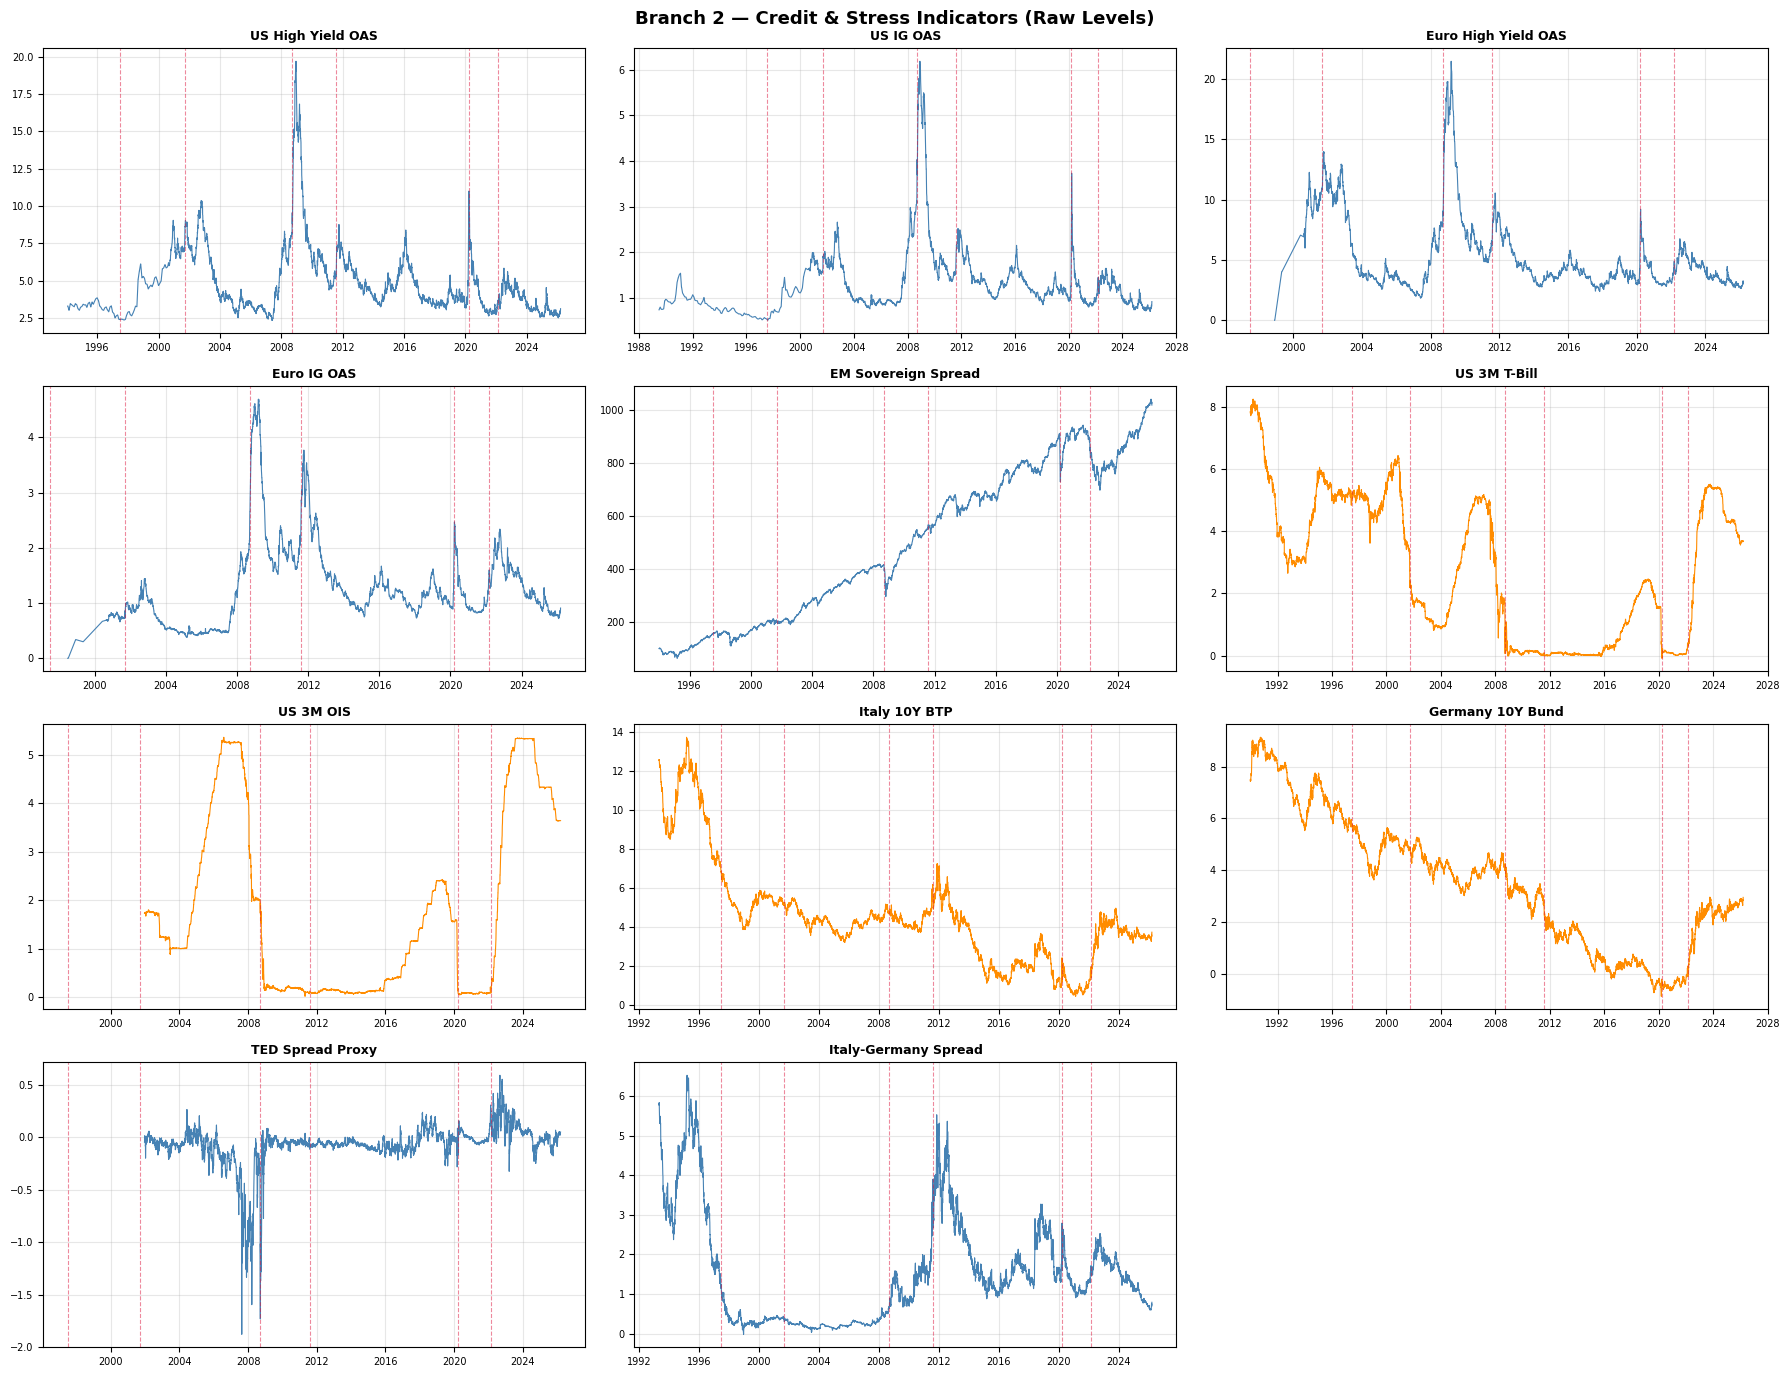


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\03_branch2_raw_levels.png


In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

# ── Load prices (we want levels for credit — spreads in basis points) ─────────
prices = pd.read_csv(cfg.ALIGNED_PRICES_FILE, index_col="date", parse_dates=True)

# ── Branch 2 tickers ──────────────────────────────────────────────────────────
CREDIT_TICKERS = {
    "LF98OAS Index":   "US High Yield OAS",
    "LUACOAS Index":   "US Investment Grade OAS",
    "LP01OAS Index":   "Euro High Yield OAS",
    "LECPOAS Index":   "Euro Investment Grade OAS",
    "JPEIGLBL Index":  "EM Sovereign Spread",
    "GB3 Govt":        "US 3M T-Bill Yield",
    "USSO3Z Curncy":   "US 3M OIS Rate",
    "GBTPGR10 Credit": "Italy 10Y BTP Yield",
    "GDBR10 Index":    "Germany 10Y Bund Yield",
}

# ── Extract levels ────────────────────────────────────────────────────────────
credit_levels = prices[list(CREDIT_TICKERS.keys())].copy()
credit_levels.dropna(how="all", inplace=True)

# ── Compute derived spreads ───────────────────────────────────────────────────
# TED spread proxy: T-Bill minus OIS — measures interbank stress
# When banks don't trust each other, T-Bill yield drops (flight to safety)
# and OIS stays elevated — spread widens = systemic stress
ted_spread = prices["GB3 Govt"] - prices["USSO3Z Curncy"]
ted_spread.name = "TED Spread Proxy"

# Italy-Germany spread: measures European sovereign/political risk
# Wider = markets demanding more premium to hold Italian debt vs German
itgerm_spread = prices["GBTPGR10 Credit"] - prices["GDBR10 Index"]
itgerm_spread.name = "Italy-Germany Spread"

print("Branch 2 — Credit & Stress Indicators")
print("="*62)
print(f"Date range : {credit_levels.dropna(how='all').index.min().date()} -> "
      f"{credit_levels.dropna(how='all').index.max().date()}")
print()
print(f"{'Indicator':<28} {'Days':>6}  {'Start':>12}  {'Current':>10}  {'Mean':>8}  {'Max':>8}")
print("-"*80)
for ticker, name in CREDIT_TICKERS.items():
    s = credit_levels[ticker].dropna()
    if not s.empty:
        print(f"  {name:<26} {len(s):>6}  {str(s.index.min().date()):>12}  "
              f"{s.iloc[-1]:>10.2f}  {s.mean():>8.2f}  {s.max():>8.2f}")

# Derived spreads
print()
print("Derived spreads:")
for spread, name in [(ted_spread, "TED Spread Proxy"), (itgerm_spread, "Italy-Germany Spread")]:
    s = spread.dropna()
    print(f"  {name:<26} {len(s):>6}  {str(s.index.min().date()):>12}  "
          f"{s.iloc[-1]:>10.2f}  {s.mean():>8.2f}  {s.max():>8.2f}")

# ── Plot all credit indicators ────────────────────────────────────────────────
CRISES = [
    ("1997-07-02", "Asia Crisis"),
    ("2001-09-11", "9/11"),
    ("2008-09-15", "Lehman"),
    ("2011-08-05", "EU Debt"),
    ("2020-03-16", "Covid"),
    ("2022-02-24", "Ukraine"),
]

fig, axes = plt.subplots(4, 3, figsize=(18, 14))
axes = axes.flatten()

plot_series = {
    "US High Yield OAS":      credit_levels["LF98OAS Index"],
    "US IG OAS":              credit_levels["LUACOAS Index"],
    "Euro High Yield OAS":    credit_levels["LP01OAS Index"],
    "Euro IG OAS":            credit_levels["LECPOAS Index"],
    "EM Sovereign Spread":    credit_levels["JPEIGLBL Index"],
    "US 3M T-Bill":           credit_levels["GB3 Govt"],
    "US 3M OIS":              credit_levels["USSO3Z Curncy"],
    "Italy 10Y BTP":          credit_levels["GBTPGR10 Credit"],
    "Germany 10Y Bund":       credit_levels["GDBR10 Index"],
    "TED Spread Proxy":       ted_spread,
    "Italy-Germany Spread":   itgerm_spread,
}

for idx, (name, series) in enumerate(plot_series.items()):
    s  = series.dropna()
    ax = axes[idx]
    color = "steelblue" if "Spread" in name or "OAS" in name else "darkorange"
    ax.plot(s.index, s.values, lw=0.8, color=color)
    ax.set_title(name, fontsize=9, fontweight="bold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)
    for crisis_date, label in CRISES:
        try:
            ax.axvline(pd.Timestamp(crisis_date), color="crimson",
                       lw=0.8, ls="--", alpha=0.5)
        except:
            pass

axes[-1].set_visible(False)

fig.suptitle("Branch 2 — Credit & Stress Indicators (Raw Levels)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "03_branch2_raw_levels.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

Credit Z-scores (current readings):
------------------------------------------------------------
  US High Yield OAS          Z= +0.47                [BENIGN]
  US IG OAS                  Z= +0.99  █             [BENIGN]
  Euro High Yield OAS        Z= +0.51  █             [BENIGN]
  Euro IG OAS                Z= +0.39                [BENIGN]
  EM Sovereign Spread        Z= +0.92  █             [BENIGN]
  TED Spread Proxy           Z= +1.31  ██            [WIDENING]
  Italy-Germany Spread       Z= -0.19                [BENIGN]

Credit Stress Score as of 2026-03-13:
  Score           : 43.9 / 100
  Regime          : BENIGN
  All-time pctile : 44.9th percentile

Regime distribution over full history:
Credit Stress Score
TIGHT       4210
BENIGN      2673
WIDENING    1880
STRESS      1535


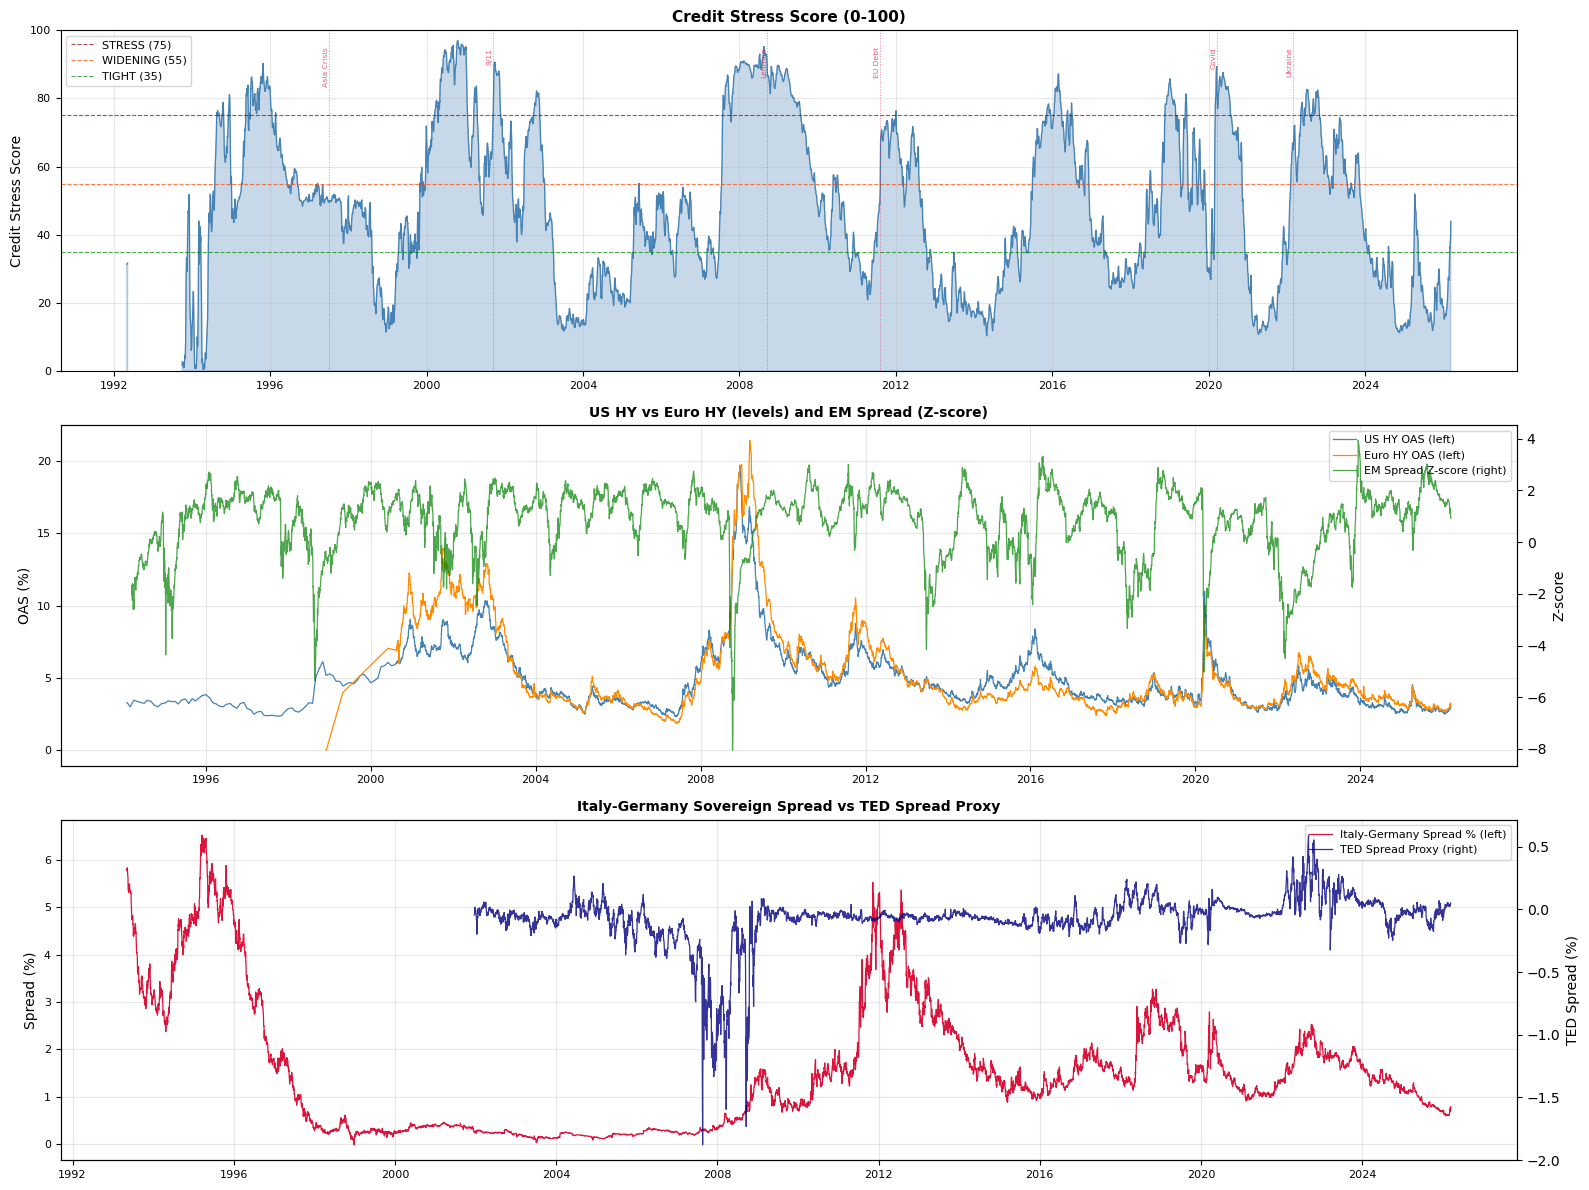


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\03_branch2_credit_score.png


In [2]:
# ── Cell 2: Credit Stress Score ──────────────────────────────────────────────

# ── Helper function ───────────────────────────────────────────────────────────
def rolling_zscore(series, window=252, min_periods=63):
    m = series.rolling(window, min_periods=min_periods).mean()
    s = series.rolling(window, min_periods=min_periods).std()
    return (series - m) / s

# ── Define the credit spread indicators ──────────────────────────────────────
# These are the pure spread/stress measures — higher = more stress
SPREAD_TICKERS = [
    "LF98OAS Index",    # US HY
    "LUACOAS Index",    # US IG
    "LP01OAS Index",    # Euro HY
    "LECPOAS Index",    # Euro IG
    "JPEIGLBL Index",   # EM sovereign
]

# ── 2A: Z-scores for all spread indicators ────────────────────────────────────
credit_zscore = pd.DataFrame(index=credit_levels.index)

for col in SPREAD_TICKERS:
    s = credit_levels[col].dropna()
    credit_zscore[col] = rolling_zscore(s)

# Z-score for derived spreads
credit_zscore["TED Spread"]          = rolling_zscore(ted_spread)
credit_zscore["Italy-Germany Spread"] = rolling_zscore(itgerm_spread)

print("Credit Z-scores (current readings):")
print("-"*60)
labels = {
    "LF98OAS Index":         "US High Yield OAS",
    "LUACOAS Index":         "US IG OAS",
    "LP01OAS Index":         "Euro High Yield OAS",
    "LECPOAS Index":         "Euro IG OAS",
    "JPEIGLBL Index":        "EM Sovereign Spread",
    "TED Spread":            "TED Spread Proxy",
    "Italy-Germany Spread":  "Italy-Germany Spread",
}
for col, name in labels.items():
    z = credit_zscore[col].dropna()
    if not z.empty:
        cur_z = z.iloc[-1]
        reg   = "STRESS" if cur_z > 2 else "WIDENING" if cur_z > 1 else "TIGHT" if cur_z < -0.5 else "BENIGN"
        bar   = "█" * min(int(abs(cur_z) * 2), 12)
        print(f"  {name:<26} Z={cur_z:>+6.2f}  {bar:<12}  [{reg}]")


# ── 2B: Credit Stress Score (0-100) ──────────────────────────────────────────
# Same methodology as Branch 1 — rolling percentile rank
PCTILE_WINDOW = 756

CREDIT_WEIGHTS = {
    "LF98OAS Index":        0.25,   # US HY — most sensitive, most liquid
    "LUACOAS Index":        0.15,   # US IG
    "LP01OAS Index":        0.20,   # Euro HY
    "LECPOAS Index":        0.10,   # Euro IG
    "JPEIGLBL Index":       0.10,   # EM sovereign
    "TED Spread":           0.10,   # Interbank stress
    "Italy-Germany Spread": 0.10,   # EU sovereign stress
}

credit_pctile = pd.DataFrame(index=credit_levels.index)

for col in SPREAD_TICKERS:
    s = credit_levels[col]
    credit_pctile[col] = s.rolling(PCTILE_WINDOW, min_periods=126).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1] * 100, raw=False
    )

# Add derived spreads
for col, series in [("TED Spread", ted_spread), ("Italy-Germany Spread", itgerm_spread)]:
    credit_pctile[col] = series.rolling(PCTILE_WINDOW, min_periods=126).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1] * 100, raw=False
    )

# Weighted score
credit_score  = pd.Series(0.0, index=credit_levels.index)
weight_avail  = pd.Series(0.0, index=credit_levels.index)

for col, weight in CREDIT_WEIGHTS.items():
    p = credit_pctile[col]
    valid = p.notna()
    credit_score[valid] += p[valid] * weight
    weight_avail[valid] += weight

credit_score = credit_score / weight_avail
credit_score = credit_score.rolling(5, min_periods=1).mean()
credit_score.name = "Credit Stress Score"

def classify_credit_regime(score):
    if   score >= 75: return "STRESS"
    elif score >= 55: return "WIDENING"
    elif score >= 35: return "BENIGN"
    else:             return "TIGHT"

credit_regime = credit_score.apply(classify_credit_regime)

current_score  = credit_score.dropna().iloc[-1]
current_regime = classify_credit_regime(current_score)
current_date   = credit_score.dropna().index[-1]

# All-time percentile
all_time_pctile = (credit_score.dropna() < current_score).sum() / len(credit_score.dropna()) * 100

print(f"\nCredit Stress Score as of {current_date.date()}:")
print(f"  Score           : {current_score:.1f} / 100")
print(f"  Regime          : {current_regime}")
print(f"  All-time pctile : {all_time_pctile:.1f}th percentile")

print(f"\nRegime distribution over full history:")
print(credit_regime.value_counts().to_string())


# ── 2C: Key spread pairs plotted together ─────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Top: Credit Stress Score
ax1 = axes[0]
ax1.fill_between(credit_score.index, credit_score.values, alpha=0.3, color="steelblue")
ax1.plot(credit_score.index, credit_score.values, lw=0.9, color="steelblue")
ax1.axhline(75, color="darkred",   lw=0.8, ls="--", alpha=0.7, label="STRESS (75)")
ax1.axhline(55, color="orangered", lw=0.8, ls="--", alpha=0.7, label="WIDENING (55)")
ax1.axhline(35, color="green",     lw=0.8, ls="--", alpha=0.7, label="TIGHT (35)")
for crisis_date, label in CRISES:
    try:
        ax1.axvline(pd.Timestamp(crisis_date), color="crimson", lw=0.7, ls=":", alpha=0.5)
        ax1.text(pd.Timestamp(crisis_date), 95, label, fontsize=5.5,
                 rotation=90, va="top", ha="right", color="crimson", alpha=0.7)
    except: pass
ax1.set_title("Credit Stress Score (0-100)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Credit Stress Score")
ax1.legend(fontsize=8, loc="upper left")
ax1.set_ylim(0, 100)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(labelsize=8); ax1.grid(alpha=0.3)

# Middle: US HY vs Euro HY vs EM
ax2 = axes[1]
ax2_twin = ax2.twinx()
ax2.plot(credit_levels["LF98OAS Index"].dropna(), lw=0.9,
         color="steelblue",  label="US HY OAS (left)")
ax2.plot(credit_levels["LP01OAS Index"].dropna(), lw=0.9,
         color="darkorange", label="Euro HY OAS (left)")
ax2_twin.plot(credit_zscore["JPEIGLBL Index"].dropna(), lw=0.9,
              color="green", alpha=0.7, label="EM Spread Z-score (right)")
ax2.set_title("US HY vs Euro HY (levels) and EM Spread (Z-score)",
              fontsize=10, fontweight="bold")
ax2.set_ylabel("OAS (%)"); ax2_twin.set_ylabel("Z-score")
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(labelsize=8); ax2.grid(alpha=0.3)

# Bottom: Italy-Germany spread and TED spread
ax3 = axes[2]
ax3_twin = ax3.twinx()
ax3.plot(itgerm_spread.dropna(), lw=0.9,
         color="crimson",   label="Italy-Germany Spread % (left)")
ax3_twin.plot(ted_spread.dropna(), lw=0.9,
              color="navy", alpha=0.8, label="TED Spread Proxy (right)")
ax3.set_title("Italy-Germany Sovereign Spread vs TED Spread Proxy",
              fontsize=10, fontweight="bold")
ax3.set_ylabel("Spread (%)"); ax3_twin.set_ylabel("TED Spread (%)")
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1+lines2, labels1+labels2, fontsize=8)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.tick_params(labelsize=8); ax3.grid(alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts", "03_branch2_credit_score.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

In [3]:
# ── Cell 3: Branch 2 Final Summary ───────────────────────────────────────────
from datetime import timedelta

latest = credit_score.dropna().index[-1]

# Regime streak
recent_regime   = credit_regime.dropna()
current_streak  = 0
for r in reversed(recent_regime.values):
    if r == classify_credit_regime(credit_score.dropna().iloc[-1]):
        current_streak += 1
    else:
        break

# Historical analogues
cur_credit_score = credit_score.dropna().iloc[-1]
score_series     = credit_score.dropna()
diffs            = (score_series - cur_credit_score).abs().sort_values()
diffs            = diffs[diffs.index < (latest - timedelta(days=90))]

# Fear vs Credit divergence (load branch 1 output)
branch1 = pd.read_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "branch1_fear_output.csv"),
    index_col="date", parse_dates=True
)
fear_now   = branch1["fear_score"].dropna().iloc[-1]
credit_now = cur_credit_score
divergence = fear_now - credit_now

def classify_divergence(fear, credit):
    if fear > 55 and credit < 45:
        return "FEAR WITHOUT CREDIT STRESS — growth scare / geopolitical, tends to resolve"
    elif fear > 55 and credit > 55:
        return "FULL STRESS — both equity and credit elevated, watch carefully"
    elif fear < 45 and credit > 55:
        return "CREDIT LEADS EQUITY — early warning, equity not pricing it yet"
    else:
        return "SYNCHRONISED CALM — risk-on environment"

div_label = classify_divergence(fear_now, credit_now)

print("=" * 62)
print("   BRANCH 2 — CREDIT STRESS REPORT")
print(f"   As of {latest.date()}")
print("=" * 62)

print(f"\n  CREDIT STRESS SCORE :  {cur_credit_score:.1f} / 100")
print(f"  REGIME              :  {classify_credit_regime(cur_credit_score)}")
print(f"  REGIME STREAK       :  {current_streak} days")
print(f"  ALL-TIME PERCENTILE :  {all_time_pctile:.1f}th percentile")

print(f"\n  ── Spread Z-scores ─────────────────────────────────")
for col, name in labels.items():
    z = credit_zscore[col].dropna()
    if not z.empty:
        cur_z = z.iloc[-1]
        reg   = "STRESS" if cur_z > 2 else "WIDENING" if cur_z > 1 else "TIGHT" if cur_z < -0.5 else "BENIGN"
        bar   = "█" * min(int(abs(cur_z) * 2), 12)
        print(f"  {name:<26} Z={cur_z:>+6.2f}  {bar:<12}  [{reg}]")

print(f"\n  ── Cross-Branch Divergence ─────────────────────────")
print(f"  Fear Score (Branch 1)   :  {fear_now:.1f}")
print(f"  Credit Score (Branch 2) :  {credit_now:.1f}")
print(f"  Divergence              :  {divergence:+.1f}")
print(f"  Interpretation          :  {div_label}")

print(f"\n  ── Closest Historical Analogues ────────────────────")
shown = []
for date, diff in diffs.items():
    if all(abs((date - d).days) > 60 for d in shown):
        regime_then  = credit_regime.get(date, "N/A")
        hy_then      = credit_levels["LF98OAS Index"].get(date, float('nan'))
        fear_then    = branch1["fear_score"].get(date, float('nan'))
        print(f"  {str(date.date())}  Credit={score_series.get(date,0):.1f}  "
              f"Fear={fear_then:.1f}  HY={hy_then:.2f}  Regime={regime_then}")
        shown.append(date)
    if len(shown) >= 5:
        break

# ── Save Branch 2 output ──────────────────────────────────────────────────────
branch2_output = pd.DataFrame({
    "credit_score":          credit_score,
    "credit_regime":         credit_regime,
    "ted_spread":            ted_spread,
    "italy_germany_spread":  itgerm_spread,
})
branch2_output.to_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "branch2_credit_output.csv")
)

print("\n" + "=" * 62)
print("  Branch 2 complete. Output saved to data/processed/regimes/")
print("=" * 62)

   BRANCH 2 — CREDIT STRESS REPORT
   As of 2026-03-13

  CREDIT STRESS SCORE :  43.9 / 100
  REGIME              :  BENIGN
  REGIME STREAK       :  9 days
  ALL-TIME PERCENTILE :  44.9th percentile

  ── Spread Z-scores ─────────────────────────────────
  US High Yield OAS          Z= +0.47                [BENIGN]
  US IG OAS                  Z= +0.99  █             [BENIGN]
  Euro High Yield OAS        Z= +0.51  █             [BENIGN]
  Euro IG OAS                Z= +0.39                [BENIGN]
  EM Sovereign Spread        Z= +0.92  █             [BENIGN]
  TED Spread Proxy           Z= +1.31  ██            [WIDENING]
  Italy-Germany Spread       Z= -0.19                [BENIGN]

  ── Cross-Branch Divergence ─────────────────────────
  Fear Score (Branch 1)   :  83.1
  Credit Score (Branch 2) :  43.9
  Divergence              :  +39.2
  Interpretation          :  FEAR WITHOUT CREDIT STRESS — growth scare / geopolitical, tends to resolve

  ── Closest Historical Analogues ───────────